In [0]:
import pandas as pd

# Objective:
1. shape, dtypes, missing values, stats, distributions, correlations
2. Choose the right visualisation library for each situation
3. Reproduce the same chart in matplotlib, seaborn, plotly - understanding the trade-offs
4. Ask and answer the analytical questions about our dataset

# EDA workflow


## Load & inspect

In [0]:
df = spark.read.table("brightlearn.brightcoffee.shop_sales").toPandas()

df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2023-01-01,2026-02-28 07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2023-01-01,2026-02-28 07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2023-01-01,2026-02-28 07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2023-01-01,2026-02-28 07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2023-01-01,2026-02-28 07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


In [0]:
print(df.shape)

(149116, 11)


In [0]:
df.sample(10)

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
41979,42086,2023-03-13,2026-02-28 08:46:30,2,5,Lower Manhattan,42,2.50,Tea,Brewed herbal tea,Lemon Grass Rg
99491,99745,2023-05-18,2026-02-28 13:31:20,2,3,Astoria,61,4.75,Drinking Chocolate,Hot chocolate,Sustainably Grown Organic Lg
112436,112694,2023-05-30,2026-02-28 12:34:56,2,3,Astoria,50,2.50,Tea,Brewed Black tea,Earl Grey Rg
60002,60172,2023-04-07,2026-02-28 10:10:27,1,5,Lower Manhattan,44,2.50,Tea,Brewed herbal tea,Peppermint Rg
85635,85809,2023-05-06,2026-02-28 10:01:44,2,5,Lower Manhattan,48,2.50,Tea,Brewed Black tea,English Breakfast Rg
60048,60218,2023-04-07,2026-02-28 10:35:10,1,5,Lower Manhattan,71,3.75,Bakery,Pastry,Chocolate Croissant
7952,7982,2023-01-15,2026-02-28 08:05:36,2,3,Astoria,51,3.00,Tea,Brewed Black tea,Earl Grey Lg
78762,78932,2023-04-28,2026-02-28 19:36:48,1,3,Astoria,47,3.00,Tea,Brewed Green tea,Serenity Green Tea Lg
100632,100886,2023-05-19,2026-02-28 11:58:12,2,5,Lower Manhattan,38,3.75,Coffee,Barista Espresso,Latte
46958,47065,2023-03-20,2026-02-28 08:21:01,1,3,Astoria,1,18.00,Coffee beans,Organic Beans,Brazilian - Organic


## Types & Columns

In [0]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   transaction_id    149116 non-null  int64         
 1   transaction_date  149116 non-null  object        
 2   transaction_time  149116 non-null  datetime64[ns]
 3   transaction_qty   149116 non-null  int64         
 4   store_id          149116 non-null  int64         
 5   store_location    149116 non-null  object        
 6   product_id        149116 non-null  int64         
 7   unit_price        149116 non-null  float64       
 8   product_category  149116 non-null  object        
 9   product_type      149116 non-null  object        
 10  product_detail    149116 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(4), object(5)
memory usage: 12.5+ MB


In [0]:
df.columns.tolist()

['transaction_id',
 'transaction_date',
 'transaction_time',
 'transaction_qty',
 'store_id',
 'store_location',
 'product_id',
 'unit_price',
 'product_category',
 'product_type',
 'product_detail']

## Missing Values

In [0]:
df.isnull()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
149111,False,False,False,False,False,False,False,False,False,False,False
149112,False,False,False,False,False,False,False,False,False,False,False
149113,False,False,False,False,False,False,False,False,False,False,False
149114,False,False,False,False,False,False,False,False,False,False,False


In [0]:
df.isnull().sum()

transaction_id      0
transaction_date    0
transaction_time    0
transaction_qty     0
store_id            0
store_location      0
product_id          0
unit_price          0
product_category    0
product_type        0
product_detail      0
dtype: int64

<Axes: >

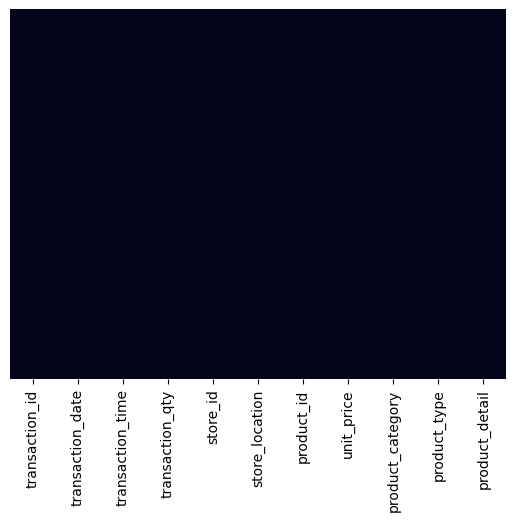

In [0]:
#visual check
import seaborn as sns
sns.heatmap(df.isnull(), cbar=False, yticklabels=False)

## Summary stats

In [0]:
# Numeric summary
df.describe()

,transaction_id,transaction_time,transaction_qty,store_id,product_id,unit_price
count,149116.000000,149116,149116.000000,149116.000000,149116.000000,149116.000000
mean,74737.371872,2026-02-28 12:14:15.815794688,1.438276,5.342063,47.918607,3.382219
min,1.000000,2026-02-28 06:00:00,1.000000,3.000000,1.000000,0.800000
25%,37335.750000,2026-02-28 09:05:10.500000,1.000000,3.000000,33.000000,2.500000
50%,74727.500000,2026-02-28 11:15:28,1.000000,5.000000,47.000000,3.000000
75%,112094.250000,2026-02-28 15:25:57,2.000000,8.000000,60.000000,3.750000
max,149456.000000,2026-02-28 20:59:32,8.000000,8.000000,87.000000,45.000000
std,43153.600016,NaN,0.542509,2.074241,17.930020,2.658723


In [0]:
# categorical summary
df.describe(include = "object")

,transaction_date,store_location,product_category,product_type,product_detail
count,149116,149116,149116,149116,149116
unique,181,3,9,29,80
top,2023-06-19,Hell's Kitchen,Coffee,Brewed Chai tea,Chocolate Croissant
freq,1343,50735,58416,17183,3076


In [0]:
# value counts for a column
df["product_category"].value_counts()

product_category
Coffee                58416
Tea                   45449
Bakery                22796
Drinking Chocolate    11468
Flavours               6790
Coffee beans           1753
Loose Tea              1210
Branded                 747
Packaged Chocolate      487
Name: count, dtype: int64

<Axes: xlabel='product_category'>

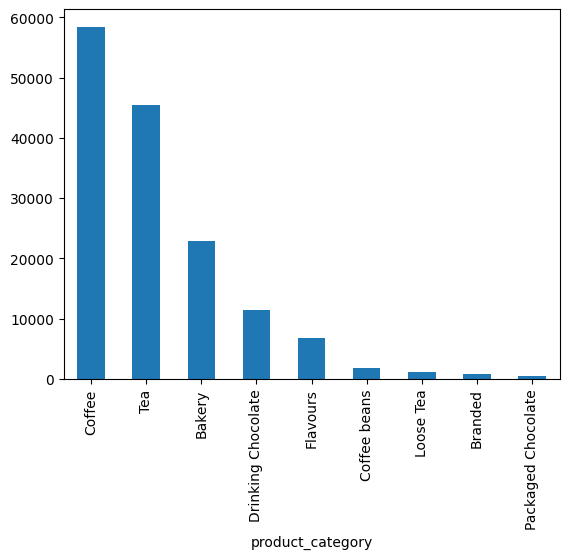

In [0]:
df["product_category"].value_counts().plot(kind="bar")

## Distribution

In [0]:
import matplotlib.pyplot as plt

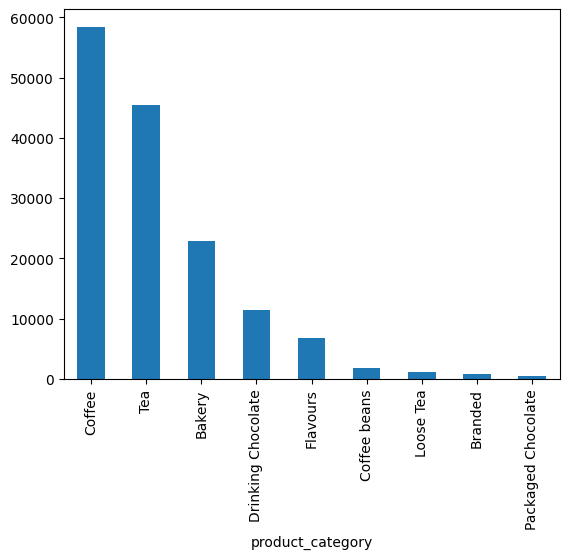

In [0]:
df["product_category"].value_counts().plot.bar() #matplotlib
plt.show()

## Relationships

In [0]:
df["Revenue"] = df["transaction_qty"]*df["unit_price"]
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,Revenue
0,1,2023-01-01,2026-02-28 07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg,6.0
1,2,2023-01-01,2026-02-28 07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2
2,3,2023-01-01,2026-02-28 07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,9.0
3,4,2023-01-01,2026-02-28 07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm,2.0
4,5,2023-01-01,2026-02-28 07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2


In [0]:
df.corr(numeric_only=True, method = "spearman")

,transaction_id,transaction_qty,store_id,product_id,unit_price,Revenue
transaction_id,1.000000,0.006562,-0.006079,0.000550,-0.002135,0.003518
transaction_qty,0.006562,1.000000,0.007938,-0.174417,-0.160442,0.680296
store_id,-0.006079,0.007938,1.000000,0.026123,-0.010181,-0.002579
product_id,0.000550,-0.174417,0.026123,1.000000,0.214682,-0.120666
unit_price,-0.002135,-0.160442,-0.010181,0.214682,1.000000,0.529418
Revenue,0.003518,0.680296,-0.002579,-0.120666,0.529418,1.000000


<Axes: >

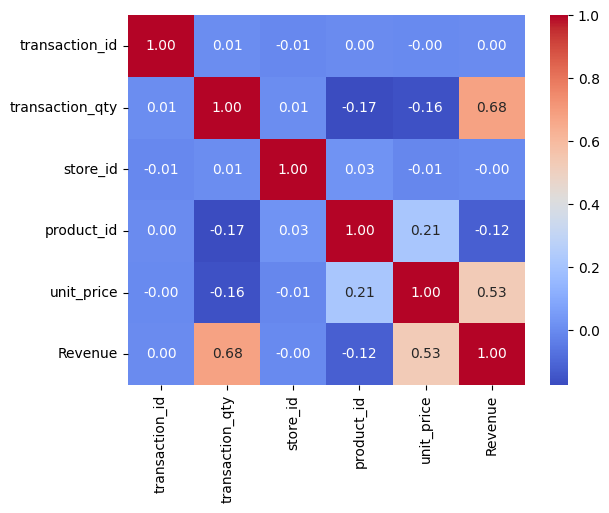

In [0]:
sns.heatmap(df.corr(numeric_only=True, method = "spearman"), annot=True, fmt=".2f", cmap="coolwarm")

<Axes: >

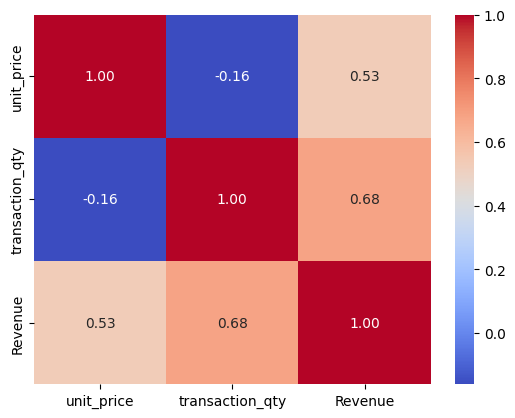

In [0]:
sns.heatmap(df[["unit_price","transaction_qty","Revenue"]].corr(numeric_only=True, method = "spearman"), annot=True, fmt=".2f", cmap="coolwarm")

## groupBy

In [0]:
#Revenue by product category

df.groupby("product_category")["Revenue"].sum().sort_values(ascending = False)

product_category
Coffee                269952.45
Tea                   196405.95
Bakery                 82315.64
Drinking Chocolate     72416.00
Coffee beans           40085.25
Branded                13607.00
Loose Tea              11213.60
Flavours                8408.80
Packaged Chocolate      4407.64
Name: Revenue, dtype: float64

In [0]:
#Average unit priceby category
df.groupby("product_category")["unit_price"].mean().round(2)

product_category
Bakery                 3.55
Branded               17.72
Coffee                 3.02
Coffee beans          21.02
Drinking Chocolate     4.15
Flavours               0.80
Loose Tea              9.27
Packaged Chocolate     9.05
Tea                    2.82
Name: unit_price, dtype: float64

In [0]:
#sale volume by store & category - pivot

pd.pivot_table(df, 
               values="transaction_qty",
               index="store_location",
               columns="product_category",
               aggfunc="sum")

product_category,Bakery,Branded,Coffee,Coffee beans,Drinking Chocolate,Flavours,Loose Tea,Packaged Chocolate,Tea
store_location,,,,,,,,,
Astoria,7496,279,29655,502,6351,2206,344,110,24048
Hell's Kitchen,7678,119,30220,790,5672,3596,485,197,22980
Lower Manhattan,8040,378,29375,536,5434,4709,381,180,22709


In [0]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   transaction_id    149116 non-null  int64         
 1   transaction_date  149116 non-null  object        
 2   transaction_time  149116 non-null  datetime64[ns]
 3   transaction_qty   149116 non-null  int64         
 4   store_id          149116 non-null  int64         
 5   store_location    149116 non-null  object        
 6   product_id        149116 non-null  int64         
 7   unit_price        149116 non-null  float64       
 8   product_category  149116 non-null  object        
 9   product_type      149116 non-null  object        
 10  product_detail    149116 non-null  object        
 11  Revenue           149116 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(4), object(5)
memory usage: 13.7+ MB


In [0]:
#parsing from datatype object to datetime
print("Data type before parsing ", df["transaction_date"].dtype)

df["transaction_date"] = pd.to_datetime(df["transaction_date"])

#Double check
print("Data type After parsing ", df["transaction_date"].dtype)

Data type before parsing  object
Data type After parsing  datetime64[ns]


In [0]:
df["Month"] = df["transaction_date"].dt.month

In [0]:
df.sample(5)

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,Revenue,Month
21546,21603,2023-02-08,2026-02-28 13:13:25,1,3,Astoria,45,3.0,Tea,Brewed herbal tea,Peppermint Lg,3.0,2
19167,19197,2023-02-04,2026-02-28 11:30:24,2,5,Lower Manhattan,23,2.5,Coffee,Drip coffee,Our Old Time Diner Blend Rg,5.0,2
62618,62788,2023-04-10,2026-02-28 09:28:05,1,8,Hell's Kitchen,17,9.5,Loose Tea,Chai tea,Morning Sunrise Chai,9.5,4
122201,122538,2023-06-08,2026-02-28 11:21:07,1,3,Astoria,49,3.0,Tea,Brewed Black tea,English Breakfast Lg,3.0,6
83310,83484,2023-05-03,2026-02-28 18:47:19,1,8,Hell's Kitchen,24,3.0,Coffee,Drip coffee,Our Old Time Diner Blend Lg,3.0,5


In [0]:
#Monthly revenue trend
monthly_trend = df.groupby("Month")["Revenue"].sum()
monthly_trend

Month
1     81677.74
2     76145.19
3     98834.68
4    118941.08
5    156727.76
6    166485.88
Name: Revenue, dtype: float64

# Viz library comparision

<Axes: xlabel='Month'>

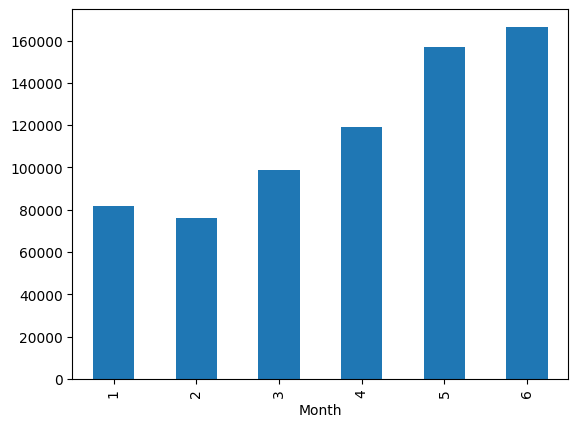

In [0]:
monthly_trend.plot(kind="bar")

## Matplotlib

Fine-grained control, custom layouts, publication figures

In [0]:
cat_rev = df.groupby("product_category")["Revenue"].sum()
cat_rev = cat_rev.sort_values(ascending=False)
cat_rev

product_category
Coffee                269952.45
Tea                   196405.95
Bakery                 82315.64
Drinking Chocolate     72416.00
Coffee beans           40085.25
Branded                13607.00
Loose Tea              11213.60
Flavours                8408.80
Packaged Chocolate      4407.64
Name: Revenue, dtype: float64

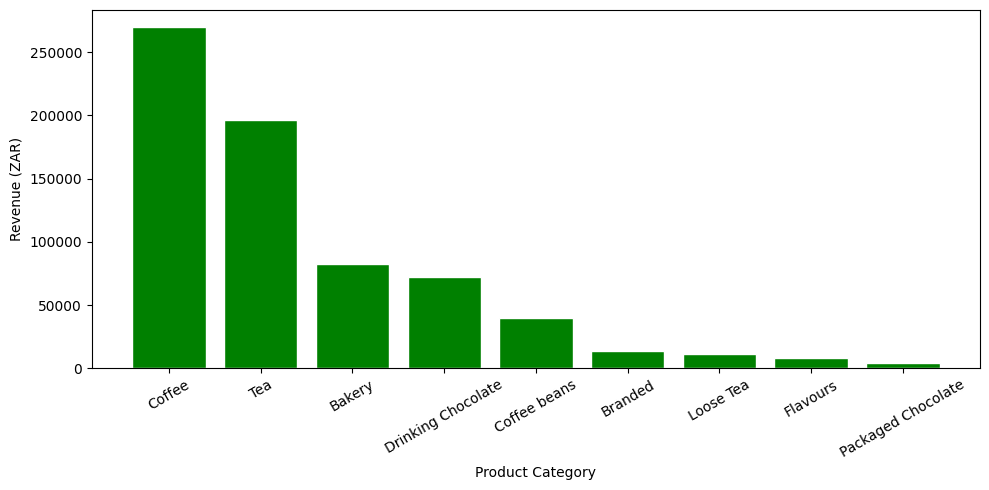

In [0]:
fig, ax = plt.subplots(figsize=(10,5))


ax.bar(cat_rev.index, cat_rev.values, color = "green", edgecolor="white")
ax.tick_params(axis="x", rotation=30)
ax.set_xlabel("Product Category")
ax.set_ylabel("Revenue (ZAR)")
plt.tight_layout()
plt.show()

## seaborn

Statistical visualization, quick attractive EDA plots

In [0]:
cat_rev = df.groupby("product_category")["Revenue"].sum().reset_index()

cat_rev.columns = ["category","revenue"]

cat_rev = cat_rev.sort_values("revenue",ascending = False)

cat_rev

,category,revenue
2,Coffee,269952.45
8,Tea,196405.95
0,Bakery,82315.64
4,Drinking Chocolate,72416.00
3,Coffee beans,40085.25
1,Branded,13607.00
6,Loose Tea,11213.60
5,Flavours,8408.80
7,Packaged Chocolate,4407.64


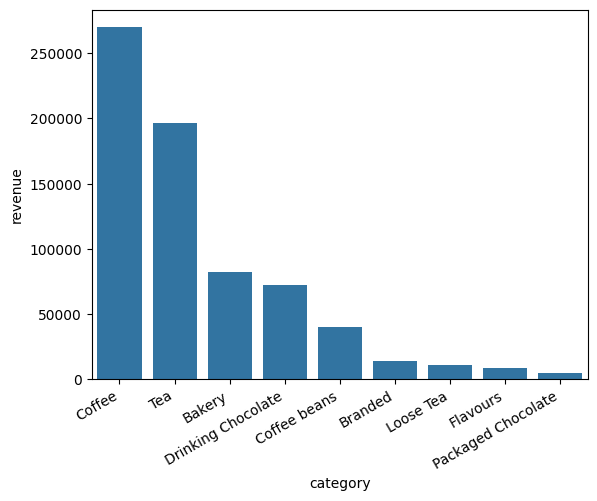

In [0]:
sns.barplot(data=cat_rev, x="category", y="revenue")
plt.xticks(rotation=30, ha="right")
plt.show()


In [0]:
df.columns

Index(['transaction_id', 'transaction_date', 'transaction_time',
       'transaction_qty', 'store_id', 'store_location', 'product_id',
       'unit_price', 'product_category', 'product_type', 'product_detail',
       'Revenue', 'Month'],
      dtype='object')

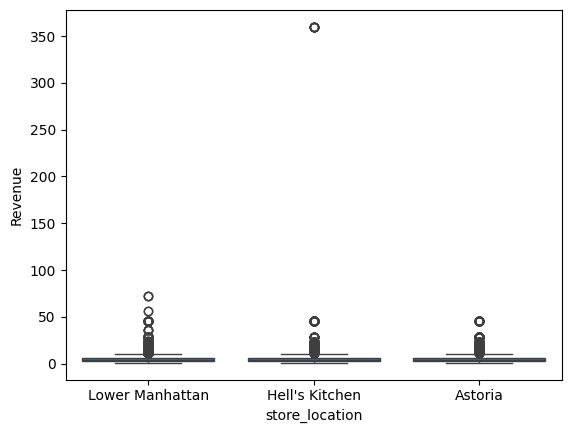

In [0]:
sns.boxplot(data=df, x="store_location", y="Revenue")
plt.show()

## Plotly

Interactive dashboards, web apps, stakeholder presentations

In [0]:
!pip install plotly

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
import plotly.express as px

In [0]:
cat_rev = df.groupby("product_category")["Revenue"].sum().reset_index()

cat_rev.columns = ["category","revenue"]

cat_rev = cat_rev.sort_values("revenue",ascending = False)

cat_rev

,category,revenue
2,Coffee,269952.45
8,Tea,196405.95
0,Bakery,82315.64
4,Drinking Chocolate,72416.00
3,Coffee beans,40085.25
1,Branded,13607.00
6,Loose Tea,11213.60
5,Flavours,8408.80
7,Packaged Chocolate,4407.64


In [0]:
fg = px.bar(cat_rev, x="category", y="revenue",
            color="revenue",
            # color_continuous_scale="Greens"
            )
fg.show()

In [0]:
monthly = df.groupby(["Month","store_location"])["Revenue"].sum().reset_index()
monthly

,Month,store_location,Revenue
0,1,Astoria,27313.66
1,1,Hell's Kitchen,27820.65
2,1,Lower Manhattan,26543.43
3,2,Astoria,25105.34
4,2,Hell's Kitchen,25719.80
5,2,Lower Manhattan,25320.05
6,3,Astoria,32835.43
7,3,Hell's Kitchen,33110.57
8,3,Lower Manhattan,32888.68
9,4,Astoria,39477.61


In [0]:
fig2 = px.line(monthly, x="Month", y="Revenue",
               color = "store_location",
               markers=True)
fig2.show()